# Resonant Frequency Post-Processing Code

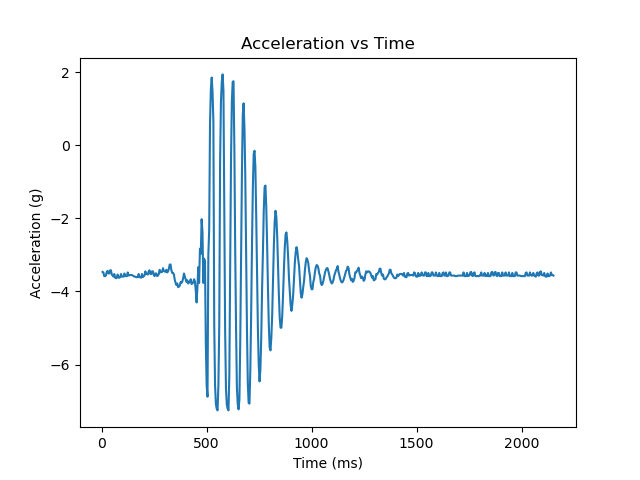

In [ ]:
# As always, we start by importing our libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd

from scipy.signal import welch # We'll need this for power spectral density estimation 

# The % sign is a Jupyter magic command that enables the use of widgets in the notebook.
# This requires installing the ipympl package.
%matplotlib widget 

# For interactive data point selection in plots, this library is useful.
import mplcursors


VCC = 5.01

# Zero g bias at 3.3 V is VCC / 2
ZERO_G_BIAS = VCC / 2

# Sensitivity at 3.3 V is ~340 mV / g
SENSITIVITY = 340e-3  # Convert to volts per g

data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/freq_2.csv")

# Convert raw Arduino data to volts
data["Voltage"] = data["Sensor 0 (raw)"] * VCC / 1023

# Subtract the zero g bias so signal is centered around 0 V
data["Voltage"] = data["Voltage"] - ZERO_G_BIAS

# Convert volts to g’s using the sensitivity
data["Acceleration (g)"] = data["Voltage"] / SENSITIVITY

# acceleration vs time plot
plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y= "Acceleration (g)", data= data)
plt.title("Acceleration vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Acceleration (g)")
mplcursors.cursor(hover=False)
plt.show()


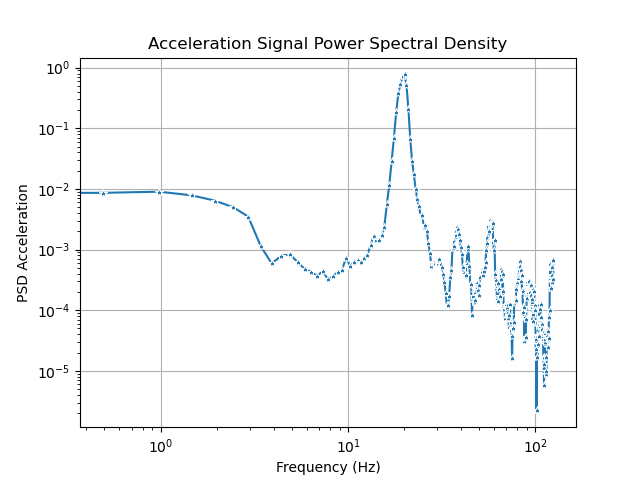

In [4]:
# Compute PSD plot

# Definte input parameters for Welch's method
segment_size = 512 # Size of each segment for Welch's method, should be a power of 2 (e.g. 256, 512, 1024, 2048, 4096)
overlap_pct = 60 # Percentage of overlap between segments, typically 25-75%
overlap_size = int(segment_size * overlap_pct / 100) # Calculate the number of samples to overlap between segments

# Calculate sampling frequency from time column
# Time is in milliseconds, so convert to seconds first
dt = data["Time (ms)"].diff().median() / 1000  # median time step in seconds
fs = 1 / dt  # sampling frequency in Hz

# Compute Power Spectral Density using Welch's method
f, pxx = welch(data['Acceleration (g)'], fs=fs, window="hann", nperseg=segment_size, noverlap=overlap_size)

# f is the frequency vector, pxx is the power spectral density estimate
# For more details, see the documentation https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html

plt.figure()
sns.lineplot(x=f, y=pxx, marker = '*')
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
#plt.xlim([20, 20000])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Acceleration')
plt.title('Acceleration Signal Power Spectral Density')
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()